# Feature Engineering for Unsupervised BIM Object Classification

Starting from 4 OBB features, we iteratively engineer geometric features for KMeans clustering.
Every claim is evaluated at k=24 over 10 random seeds (mean ± std).

**Dataset:** 1,889 human-annotated BIM objects, 24 IFC types.

In [31]:
import sys, json, warnings
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import trimesh
from pathlib import Path
from scipy.stats import skew, entropy
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [32]:
df_all = pd.read_parquet('../../processed_data/features/train_features.parquet')
with open('../../data/annotated_subset.json') as f:
    annotated = json.load(f)
annotated_gids = [d['GlobalId'] for d in annotated]
df = df_all[df_all['GlobalId'].isin(set(annotated_gids))].copy().reset_index(drop=True)
mesh_dir = Path('../../processed_data/meshes/train')

BASELINE = ['Length', 'CrossSectionArea', 'Volume', 'NumVertices']
Z_AXIS = np.array([0, 0, 1])
SEEDS = list(range(42, 52))
ifc_types = df['IfcType'].values

def compute_purity(labels, true_labels):
    return sum(pd.Series(true_labels[labels == c]).value_counts().iloc[0]
               for c in np.unique(labels)) / len(labels)

def eval_k24(X, labels, seeds=SEEDS, scale=True):
    """Evaluate k=24 KMeans over multiple seeds. Returns dict of metric arrays."""
    if scale:
        X = RobustScaler().fit_transform(X)
    metrics = {'purity': [], 'silhouette': [], 'davies_bouldin': [], 'calinski_harabasz': []}
    for s in seeds:
        lab = MiniBatchKMeans(24, batch_size=1024, n_init='auto', random_state=s).fit_predict(X)
        metrics['purity'].append(compute_purity(lab, labels))
        metrics['silhouette'].append(silhouette_score(X, lab))
        metrics['davies_bouldin'].append(davies_bouldin_score(X, lab))
        metrics['calinski_harabasz'].append(calinski_harabasz_score(X, lab))
    return {k: (np.mean(v), np.std(v)) for k, v in metrics.items()}

print(f'{len(df):,} objects, {df["IfcType"].nunique()} types\n')
print(df['IfcType'].value_counts().sort_index().to_string())

1,845 objects, 24 types

IfcType
IfcBeam                        90
IfcBuildingElementPart         95
IfcBuildingElementProxy        54
IfcColumn                      79
IfcCovering                    99
IfcCurtainWall                 42
IfcDistributionFlowElement    100
IfcDoor                        70
IfcFlowTerminal                78
IfcFooting                     89
IfcFurnishingElement           78
IfcFurniture                   90
IfcLightFixture                46
IfcMember                      50
IfcPlate                       68
IfcRailing                     85
IfcRoof                        46
IfcSlab                        95
IfcStair                       75
IfcStairFlight                 92
IfcSystemFurnitureElement      90
IfcWall                        81
IfcWallStandardCase            76
IfcWindow                      77


## 1. Baseline Feature Distributions

The 4 OBB features span orders of magnitude. We compare three scaling strategies:
- **Raw**: no transformation — skewed, outlier-dominated
- **RobustScaler**: centers on median, scales by IQR — still skewed, just rescaled
- **Log + RobustScaler**: log1p compresses the range first, then RobustScaler normalizes — symmetric, spread out

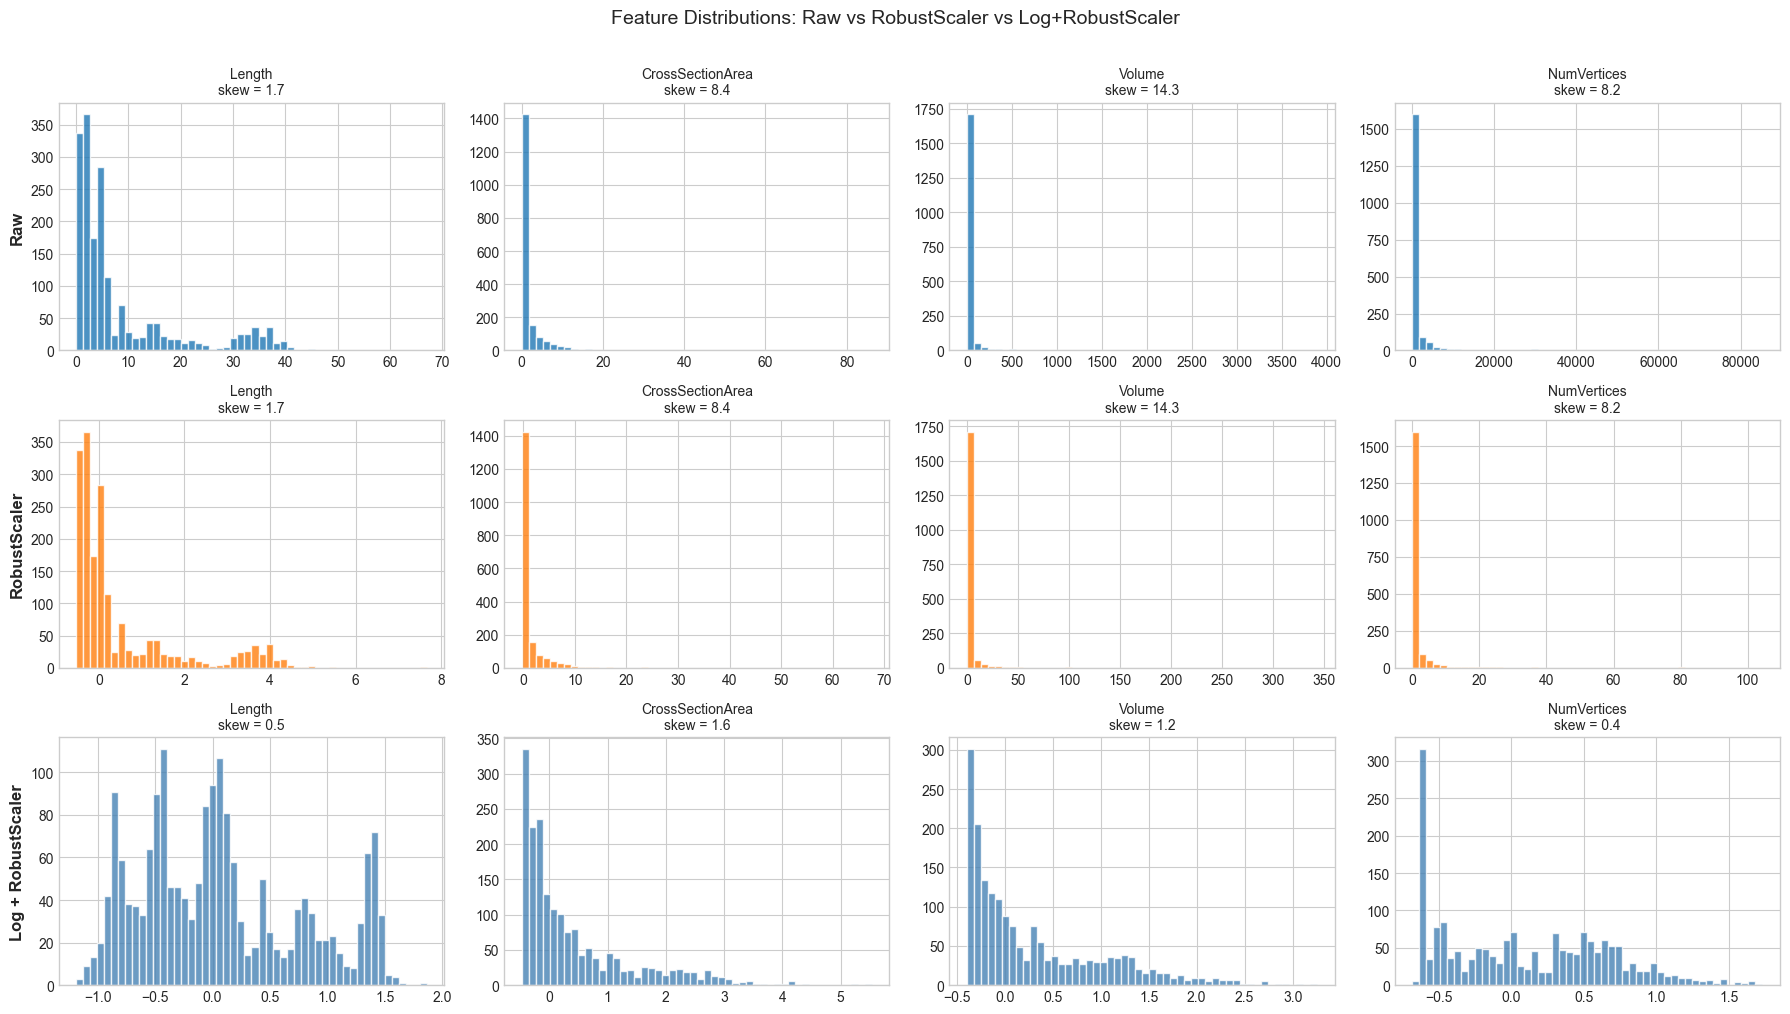

In [33]:
X_raw = df[BASELINE].clip(lower=0).values
X_robust = RobustScaler().fit_transform(X_raw)
X_log_robust = RobustScaler().fit_transform(np.log1p(X_raw))

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
transforms = [
    ('Raw', X_raw, 'tab:blue'),
    ('RobustScaler', X_robust, 'tab:orange'),
    ('Log + RobustScaler', X_log_robust, 'steelblue'),
]
for row, (label, X, color) in enumerate(transforms):
    for i, col in enumerate(BASELINE):
        ax = axes[row, i]
        vals = X[:, i]
        ax.hist(vals, bins=50, edgecolor='white', alpha=0.8, color=color)
        ax.set_title(f'{col}\nskew = {skew(vals):.1f}', fontsize=10)
        if i == 0:
            ax.set_ylabel(label, fontsize=12, fontweight='bold')
plt.suptitle('Feature Distributions: Raw vs RobustScaler vs Log+RobustScaler', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [34]:
X_raw = df[BASELINE].clip(lower=0).values
X_log = np.log1p(X_raw)

r_raw_ns = eval_k24(X_raw, ifc_types, scale=False)
r_raw = eval_k24(X_raw, ifc_types)
r_log = eval_k24(X_log, ifc_types)

header = f'{"Config":<30} {"Purity":>13} {"Silhouette":>13} {"DB (↓)":>13} {"CH (↑)":>13}'
print(header)
print('-' * len(header))
for label, r in [('Raw (no scaling)', r_raw_ns), ('Raw + RobustScaler', r_raw), ('Log + RobustScaler', r_log)]:
    print(f'{label:<30} {r["purity"][0]:.3f}±{r["purity"][1]:.3f}'
          f' {r["silhouette"][0]:.3f}±{r["silhouette"][1]:.3f}'
          f' {r["davies_bouldin"][0]:.3f}±{r["davies_bouldin"][1]:.3f}'
          f' {r["calinski_harabasz"][0]:.0f}±{r["calinski_harabasz"][1]:.0f}')

Config                                Purity    Silhouette        DB (↓)        CH (↑)
--------------------------------------------------------------------------------------
Raw (no scaling)               0.246±0.008 0.441±0.061 0.660±0.032 1634±554
Raw + RobustScaler             0.260±0.015 0.296±0.026 0.890±0.024 422±47
Log + RobustScaler             0.330±0.013 0.311±0.017 1.034±0.038 1095±26


## 2. PCA on Mesh Vertices — Orientation Features

The baseline features describe bounding box **size** but not **orientation**. A Column and a Beam can have identical OBBs — one is vertical, the other horizontal.

We apply PCA to the raw 3D vertex coordinates of each mesh. The eigenvectors give us the principal axes of the object's shape. The dot product of these axes with the gravity vector Z = [0,0,1] encodes orientation:
- `pc1_z = |dot(longest axis, Z)|` — 1.0 if the object stands upright, 0.0 if it lies flat
- `pc3_z = |dot(thinnest axis, Z)|` — 1.0 for slabs (thin vertically), 0.0 for walls (thin horizontally)

The PCA eigenvalues also give us cross-section shape, and while loading meshes we compute convexity and normal entropy.

In [35]:
# Reference directions for normal entropy binning (42 directions on unit sphere)
ref_dirs = np.array(trimesh.creation.icosphere(subdivisions=1).vertices)
ref_dirs = ref_dirs / np.linalg.norm(ref_dirs, axis=1, keepdims=True)
N_BINS = len(ref_dirs)

engineered = []
for i, gid in enumerate(annotated_gids):
    mesh_path = mesh_dir / f'{gid}.obj'
    if not mesh_path.exists():
        continue
    mesh = trimesh.load(mesh_path, force='mesh', process=False)
    verts = np.array(mesh.vertices)
    if len(verts) < 3:
        continue

    # PCA on vertex positions
    pca = PCA(n_components=3).fit(verts)

    # Orientation: eigenvector directions vs Z-axis
    pc1_z = abs(np.dot(pca.components_[0], Z_AXIS))
    pc3_z = abs(np.dot(pca.components_[2], Z_AXIS))

    # Cross-section aspect ratio: eigenvalue ratio
    extents = np.sqrt(pca.explained_variance_)
    cs_ratio = extents[2] / extents[1] if extents[1] > 1e-8 else 0.0

    # Normal entropy: how spread out are face normal directions?
    normals = mesh.face_normals
    areas = mesh.area_faces
    if len(normals) > 0 and len(areas) > 0:
        dots = normals @ ref_dirs.T
        bins = dots.argmax(axis=1)
        hist = np.bincount(bins, weights=areas, minlength=N_BINS)
        hist = hist / hist.sum()
        norm_ent = entropy(hist) / np.log(N_BINS)
    else:
        norm_ent = 0.0

    # Horizontal surface fraction: what proportion of surface area faces up/down?
    if len(normals) > 0 and len(areas) > 0:
        z_component = np.abs(normals @ Z_AXIS)
        horiz_area = areas[z_component > 0.9].sum()
        horiz_frac = horiz_area / areas.sum()
    else:
        horiz_frac = 0.0

    engineered.append({'GlobalId': gid, 'pc1_z': pc1_z, 'pc3_z': pc3_z,
                       'cs_aspect_ratio': cs_ratio,
                       'normal_entropy': norm_ent, 'horiz_frac': horiz_frac})
    if (i + 1) % 500 == 0:
        print(f'{i+1}/{len(annotated_gids)}...')

df_eng = pd.DataFrame(engineered)
df_feat = df.merge(df_eng, on='GlobalId')
ifc_types_feat = df_feat['IfcType'].values

print(f'\nExtracted features for {len(df_feat)} objects')
print(df_eng.describe().round(3))

500/1849...
1000/1849...
1500/1849...

Extracted features for 1849 objects
          pc1_z     pc3_z  cs_aspect_ratio  normal_entropy  horiz_frac
count  1849.000  1849.000         1849.000        1849.000    1849.000
mean      0.378     0.440            0.364           0.439       0.364
std       0.435     0.452            0.307           0.175       0.317
min       0.000     0.000            0.002           0.194       0.000
25%       0.000     0.000            0.067           0.300       0.060
50%       0.040     0.208            0.319           0.412       0.314
75%       0.917     0.995            0.591           0.533       0.586
max       1.000     1.000            1.000           0.981       0.995


### 2.1 Orientation per IFC Type

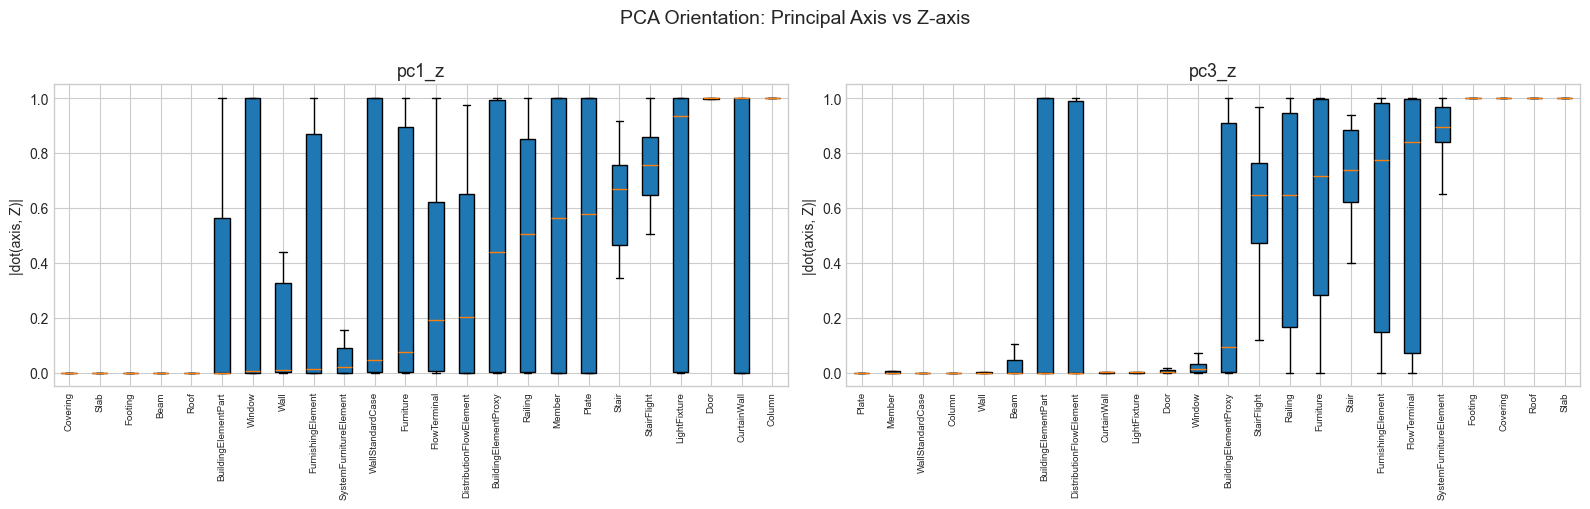

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for i, feat in enumerate(['pc1_z', 'pc3_z']):
    ax = axes[i]
    order = df_feat.groupby('IfcType')[feat].median().sort_values().index
    data = [df_feat.loc[df_feat['IfcType'] == t, feat].values for t in order]
    ax.boxplot(data, vert=True, patch_artist=True, showfliers=False)
    ax.set_xticklabels([t.replace('Ifc', '') for t in order], rotation=90, fontsize=7)
    ax.set_title(feat, fontsize=13)
    ax.set_ylabel('|dot(axis, Z)|')
plt.suptitle('PCA Orientation: Principal Axis vs Z-axis', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [37]:
X_base_log = np.log1p(df_feat[BASELINE].clip(lower=0).values)
X_plus_orient = np.hstack([X_base_log, df_feat[['pc1_z', 'pc3_z']].values])

r_b = eval_k24(X_base_log, ifc_types_feat)
r_o = eval_k24(X_plus_orient, ifc_types_feat)

header = f'{"Config":<30} {"Purity":>13} {"Silhouette":>13} {"DB (↓)":>13} {"CH (↑)":>13} {"Dims":>5}'
print(header)
print('-' * len(header))
for label, r, d in [('Log baseline', r_b, 4), ('+ Orientation', r_o, 6)]:
    print(f'{label:<30} {r["purity"][0]:.3f}±{r["purity"][1]:.3f}'
          f' {r["silhouette"][0]:.3f}±{r["silhouette"][1]:.3f}'
          f' {r["davies_bouldin"][0]:.3f}±{r["davies_bouldin"][1]:.3f}'
          f' {r["calinski_harabasz"][0]:.0f}±{r["calinski_harabasz"][1]:.0f}'
          f' {d:>5}')
print(f'\nOrientation adds: +{r_o["purity"][0] - r_b["purity"][0]:.3f} purity')

Config                                Purity    Silhouette        DB (↓)        CH (↑)  Dims
--------------------------------------------------------------------------------------------
Log baseline                   0.330±0.009 0.321±0.008 0.996±0.024 1109±27     4
+ Orientation                  0.375±0.006 0.325±0.007 1.100±0.036 624±15     6

Orientation adds: +0.046 purity


---
## 3. More Mesh Features

Building on the log baseline + orientation, we add three more features from the mesh geometry.

### 3.3 Cross-Section Aspect Ratio (from PCA eigenvalues)

**Problem:** A Column and a Plate are both elongated and solid, but a column has a square cross-section while a plate is very thin.

**Feature:** sqrt(λ₃) / sqrt(λ₂) from the same PCA decomposition used for orientation. The ratio of the two shorter axes: 1.0 = square cross-section, ~0 = infinitely thin.

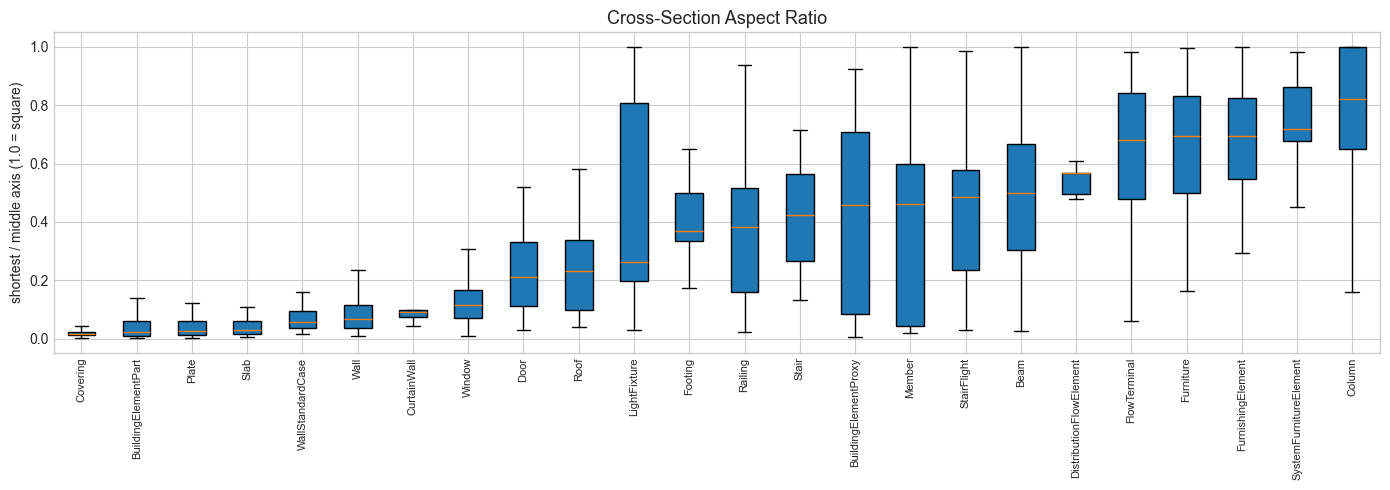

In [38]:
fig, ax = plt.subplots(figsize=(14, 5))
order = df_feat.groupby('IfcType')['cs_aspect_ratio'].median().sort_values().index
data = [df_feat.loc[df_feat['IfcType'] == t, 'cs_aspect_ratio'].values for t in order]
ax.boxplot(data, vert=True, patch_artist=True, showfliers=False)
ax.set_xticklabels([t.replace('Ifc', '') for t in order], rotation=90, fontsize=8)
ax.set_title('Cross-Section Aspect Ratio', fontsize=13)
ax.set_ylabel('shortest / middle axis (1.0 = square)')
plt.tight_layout()
plt.show()

### 3.4 Normal Entropy — Surface Complexity

**Problem:** A Slab and a Railing can have the same OBB, orientation, and cross-section — but a slab is a flat sheet (2 dominant normal directions: top/bottom) while a railing has bars, posts, and rails pointing in every direction.

**Feature:** Shannon entropy of the area-weighted face normal distribution, binned into 42 icosphere directions and normalized to [0, 1].
- 0 = all surface area faces one direction (flat slab)
- 1 = normals uniformly spread across all directions (complex geometry)

This is genuinely orthogonal to all existing features — no combination of OBB dimensions or orientation encodes surface detail.

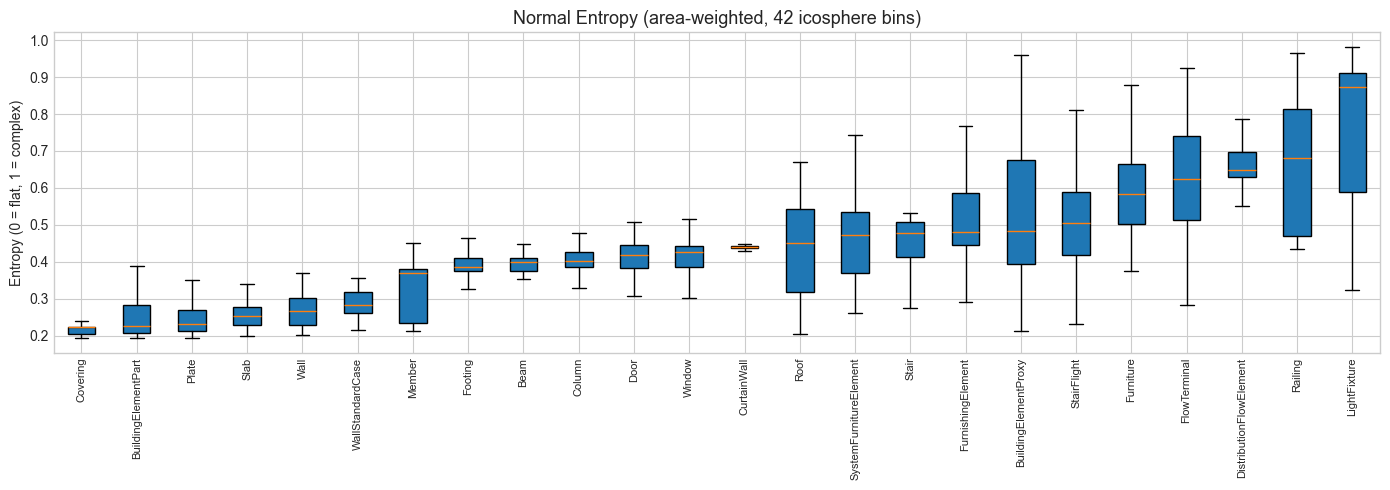

In [39]:
fig, ax = plt.subplots(figsize=(14, 5))
order = df_feat.groupby('IfcType')['normal_entropy'].median().sort_values().index
data = [df_feat.loc[df_feat['IfcType'] == t, 'normal_entropy'].values for t in order]
ax.boxplot(data, vert=True, patch_artist=True, showfliers=False)
ax.set_xticklabels([t.replace('Ifc', '') for t in order], rotation=90, fontsize=8)
ax.set_title('Normal Entropy (area-weighted, 42 icosphere bins)', fontsize=13)
ax.set_ylabel('Entropy (0 = flat, 1 = complex)')
plt.tight_layout()
plt.show()

### 3.5 Horizontal Surface Fraction — Directional Composition

**Problem:** Normal entropy tells us *how spread out* normals are, but not *where* they point. A Slab and a Roof can have similar entropy (both have a few dominant directions), but a slab's surfaces face straight up/down while a roof's surfaces are angled.

**Feature:** Fraction of total surface area where `|normal · Z| > 0.9` — i.e., faces that are nearly horizontal. Bounded [0, 1].
- ~1.0 for slabs (almost all surface is top/bottom)
- ~0.0 for walls (almost all surface is vertical)
- moderate for roofs (angled), stairs (horizontal treads + vertical risers)

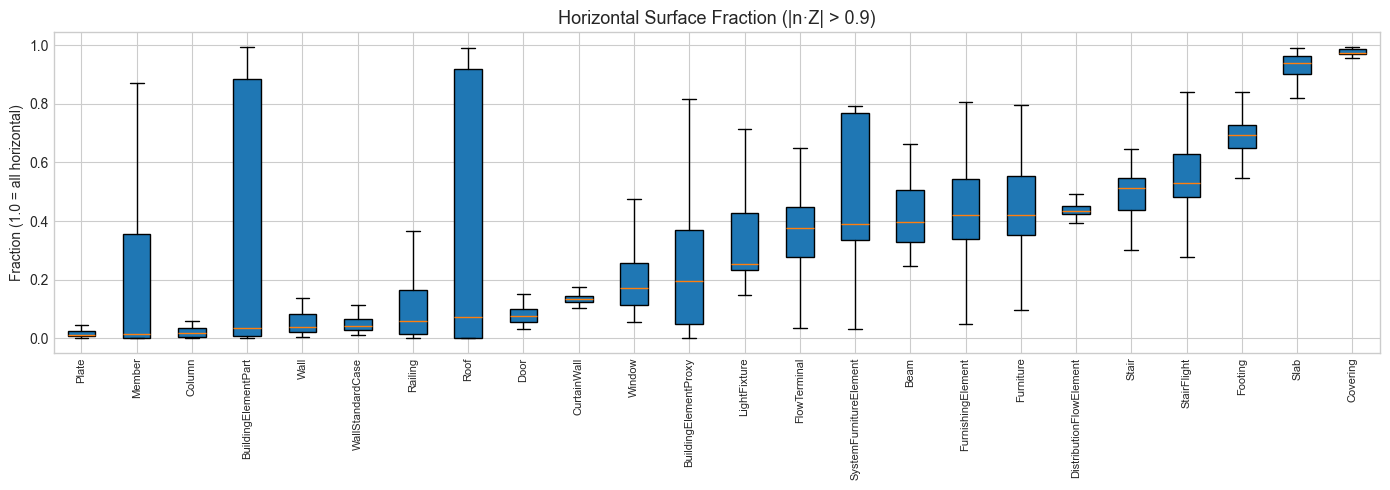

In [40]:
fig, ax = plt.subplots(figsize=(14, 5))
order = df_feat.groupby('IfcType')['horiz_frac'].median().sort_values().index
data = [df_feat.loc[df_feat['IfcType'] == t, 'horiz_frac'].values for t in order]
ax.boxplot(data, vert=True, patch_artist=True, showfliers=False)
ax.set_xticklabels([t.replace('Ifc', '') for t in order], rotation=90, fontsize=8)
ax.set_title('Horizontal Surface Fraction (|n·Z| > 0.9)', fontsize=13)
ax.set_ylabel('Fraction (1.0 = all horizontal)')
plt.tight_layout()
plt.show()

---
## 4. Incremental Evaluation

Each feature is added to the log baseline. All results: k=24, 10 seeds, mean ± std.

Config                           Purity    Silhouette        DB (↓)        CH (↑)
---------------------------------------------------------------------------------
Baseline (4, raw)         0.248±0.016 0.309±0.022 0.893±0.028 489±143
Baseline (4, log)         0.330±0.009 0.321±0.008 0.996±0.024 1109±27
+ Orientation (6)         0.375±0.006 0.325±0.007 1.100±0.036 624±15
+ CS Ratio (7)            0.431±0.018 0.286±0.008 1.212±0.032 461±9
+ Normal Entropy (8)      0.453±0.012 0.268±0.013 1.282±0.024 391±9
+ Horiz Frac (9)          0.470±0.016 0.277±0.012 1.242±0.024 384±7


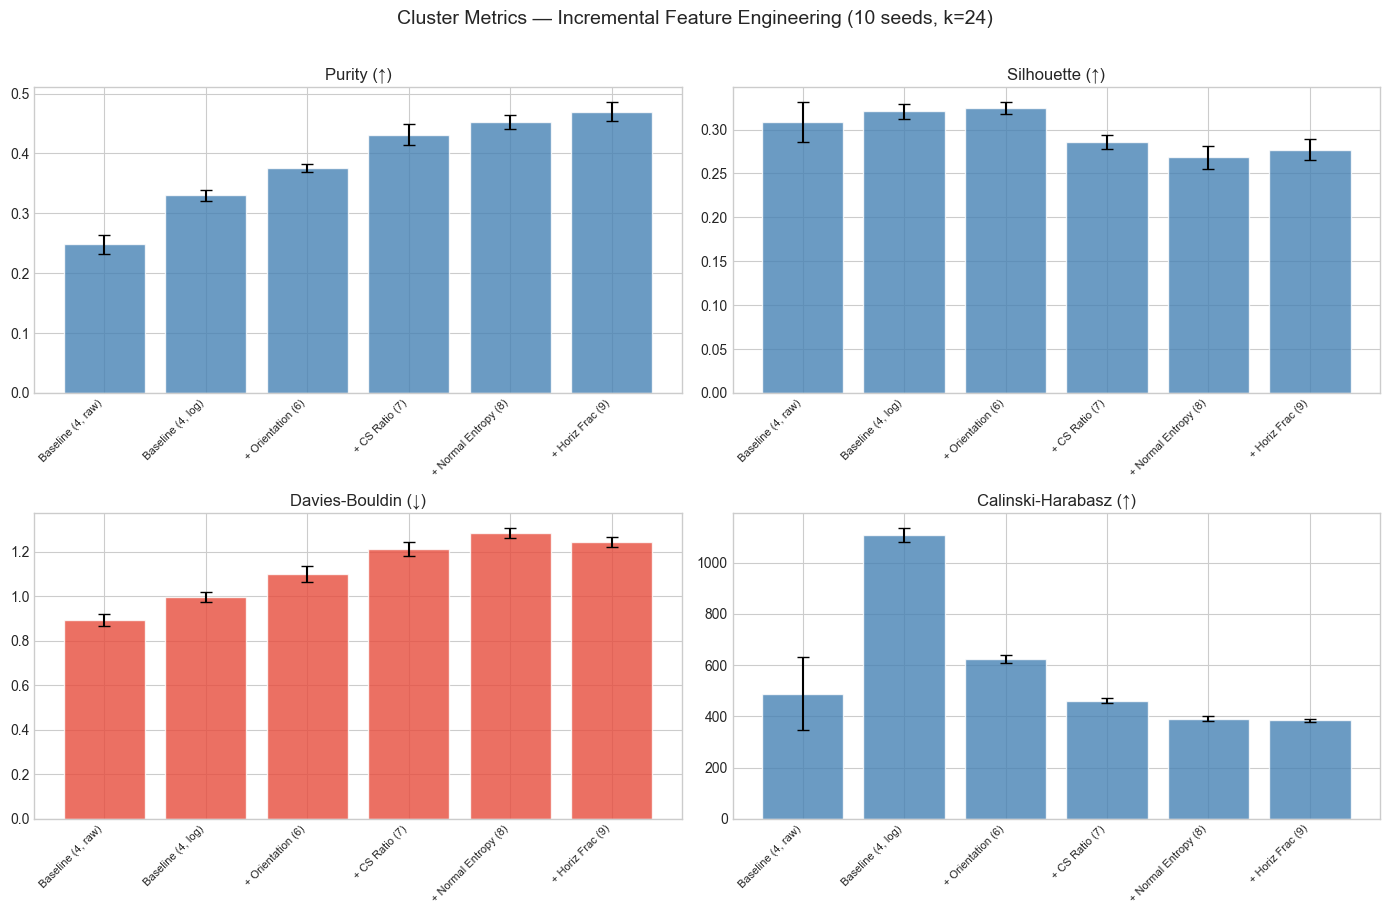

In [41]:
ENG_BOUNDED = ['pc1_z', 'pc3_z', 'cs_aspect_ratio']  # [0,1] — use as-is

def build_features(df, baseline_cols, bounded_eng=None):
    """Log-transform baseline; pass [0,1] features through as-is."""
    X = np.log1p(df[baseline_cols].clip(lower=0).values)
    if bounded_eng:
        X = np.hstack([X, df[bounded_eng].values])
    return X

configs = {
    'Baseline (4, raw)': df_feat[BASELINE].clip(lower=0).values,
    'Baseline (4, log)': build_features(df_feat, BASELINE),
    '+ Orientation (6)': build_features(df_feat, BASELINE, bounded_eng=['pc1_z', 'pc3_z']),
    '+ CS Ratio (7)': build_features(df_feat, BASELINE, bounded_eng=ENG_BOUNDED),
    '+ Normal Entropy (8)': build_features(df_feat, BASELINE, bounded_eng=ENG_BOUNDED + ['normal_entropy']),
    '+ Horiz Frac (9)': build_features(df_feat, BASELINE, bounded_eng=ENG_BOUNDED + ['normal_entropy', 'horiz_frac']),
}

results = {}
header = f'{"Config":<25} {"Purity":>13} {"Silhouette":>13} {"DB (↓)":>13} {"CH (↑)":>13}'
print(header)
print('-' * len(header))
for name, X in configs.items():
    r = eval_k24(X, ifc_types_feat)
    results[name] = r
    print(f'{name:<25} {r["purity"][0]:.3f}±{r["purity"][1]:.3f}'
          f' {r["silhouette"][0]:.3f}±{r["silhouette"][1]:.3f}'
          f' {r["davies_bouldin"][0]:.3f}±{r["davies_bouldin"][1]:.3f}'
          f' {r["calinski_harabasz"][0]:.0f}±{r["calinski_harabasz"][1]:.0f}')

# Progression plot — all 4 metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
names = list(results.keys())
x = range(len(names))

for ax, metric, title, higher_better in [
    (axes[0, 0], 'purity', 'Purity (↑)', True),
    (axes[0, 1], 'silhouette', 'Silhouette (↑)', True),
    (axes[1, 0], 'davies_bouldin', 'Davies-Bouldin (↓)', False),
    (axes[1, 1], 'calinski_harabasz', 'Calinski-Harabasz (↑)', True),
]:
    means = [results[n][metric][0] for n in names]
    stds = [results[n][metric][1] for n in names]
    color = 'steelblue' if higher_better else '#e74c3c'
    ax.bar(x, means, yerr=stds, capsize=4, color=color, alpha=0.8, edgecolor='white')
    ax.set_xticks(list(x))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontsize=12)

plt.suptitle('Cluster Metrics — Incremental Feature Engineering (10 seeds, k=24)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

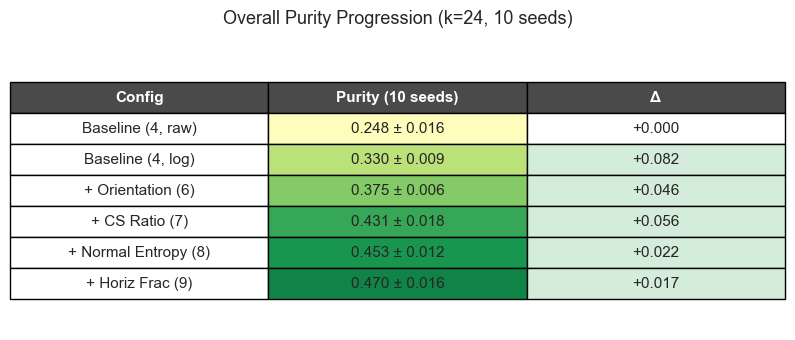

In [42]:
# Pretty table: Overall purity progression
purity_data = []
prev_purity = None
for name in configs.keys():
    p_mean, p_std = results[name]['purity']
    delta = p_mean - prev_purity if prev_purity is not None else 0
    purity_data.append({
        'Config': name,
        'Purity': f'{p_mean:.3f} ± {p_std:.3f}',
        'Δ': f'+{delta:.3f}' if delta >= 0 else f'{delta:.3f}',
        'purity_val': p_mean
    })
    prev_purity = p_mean

df_purity = pd.DataFrame(purity_data)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.axis('off')

cell_text = df_purity[['Config', 'Purity', 'Δ']].values.tolist()
col_labels = ['Config', 'Purity (10 seeds)', 'Δ']

table = ax.table(cellText=cell_text, colLabels=col_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

for i, row in enumerate(purity_data):
    color = plt.cm.RdYlGn(row['purity_val'] / 0.5)
    table[(i + 1, 1)].set_facecolor(color)
    delta_val = float(row['Δ'].replace('+', ''))
    if delta_val > 0:
        table[(i + 1, 2)].set_facecolor('#d4edda')
    elif delta_val < 0:
        table[(i + 1, 2)].set_facecolor('#f8d7da')

for j in range(3):
    table[(0, j)].set_facecolor('#4a4a4a')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

ax.set_title('Overall Purity Progression (k=24, 10 seeds)', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

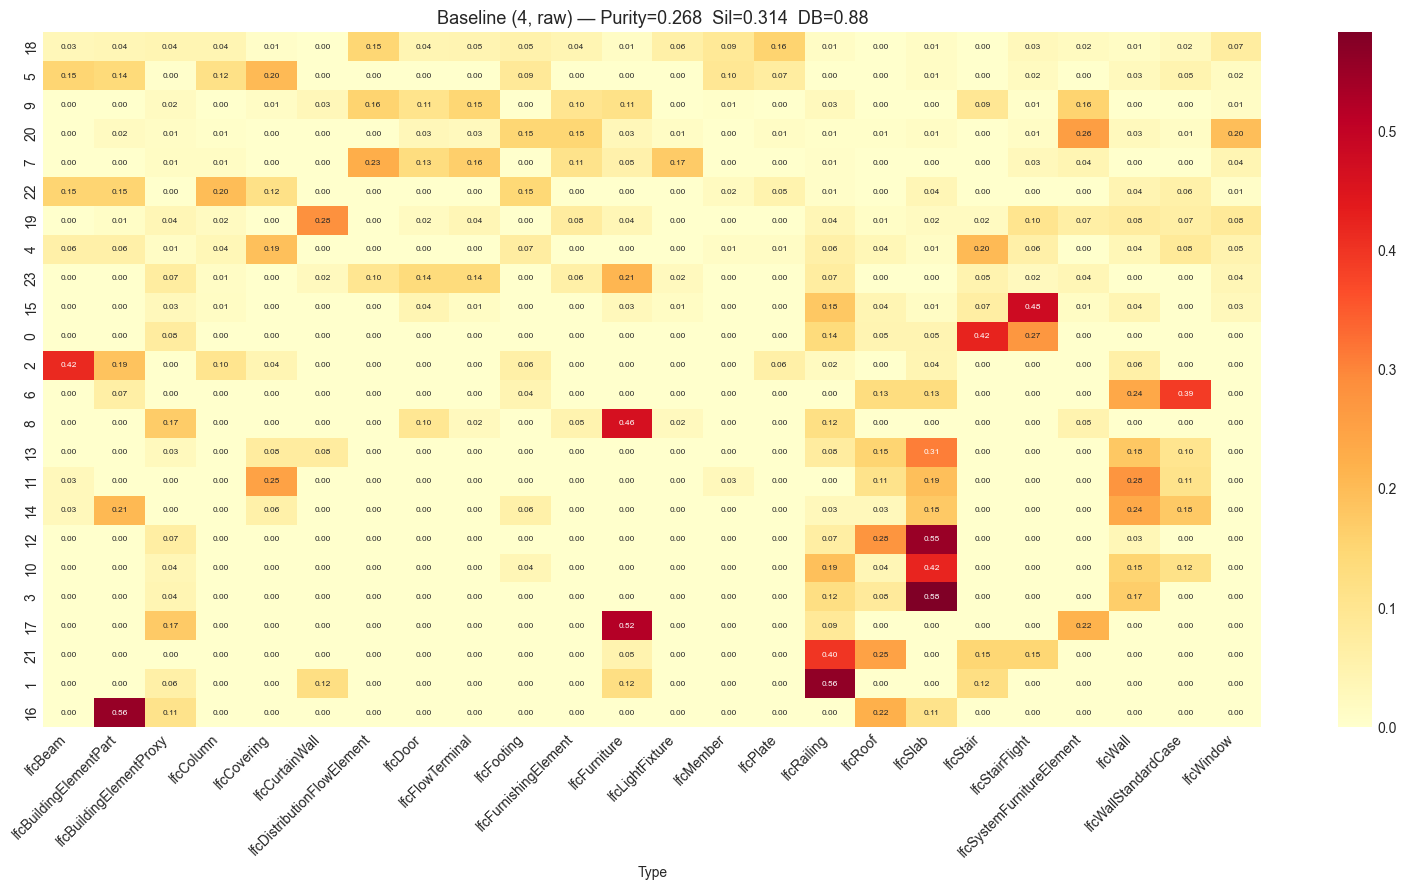

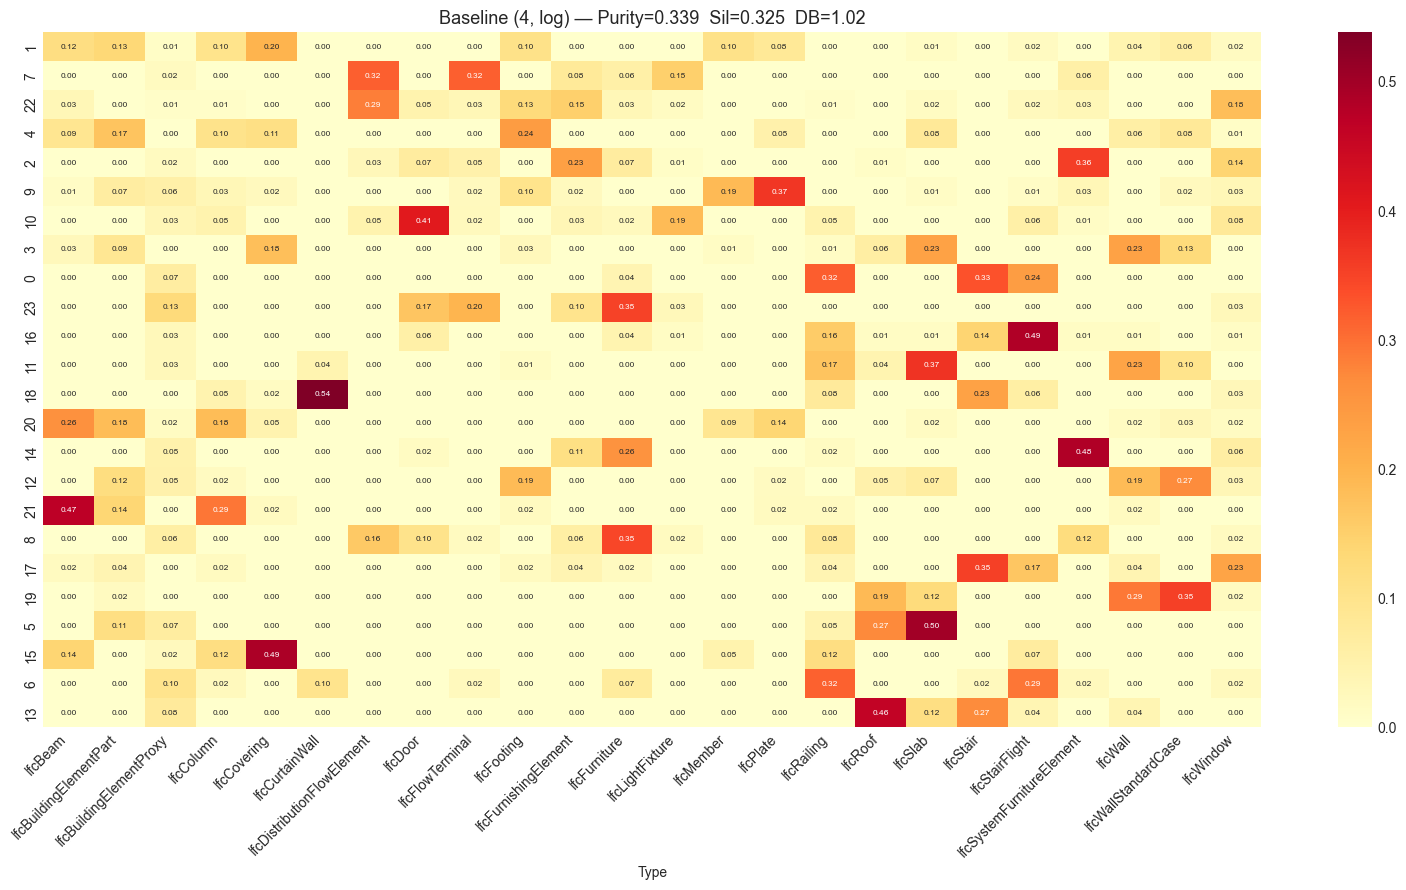

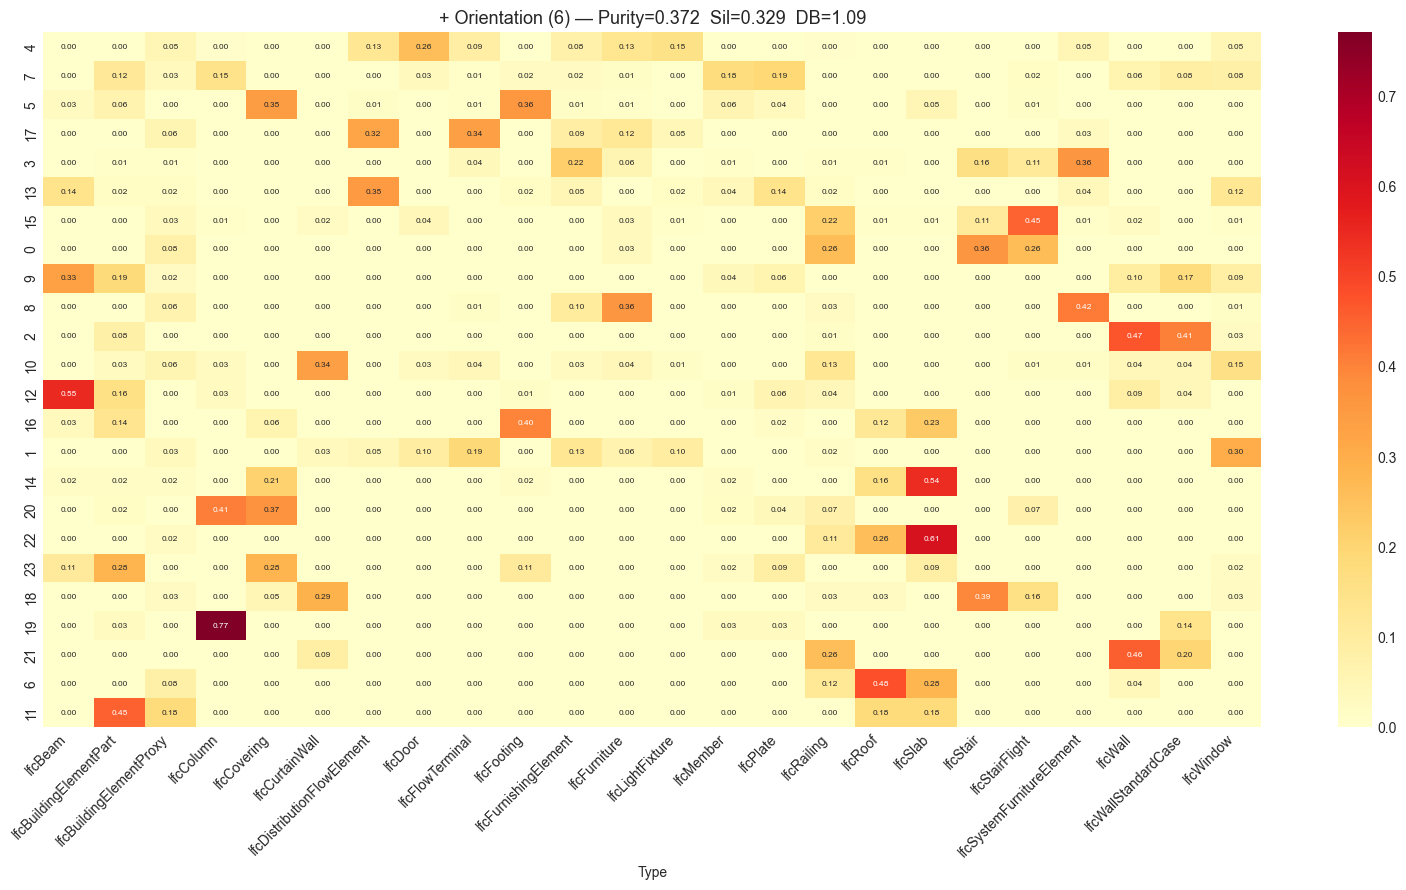

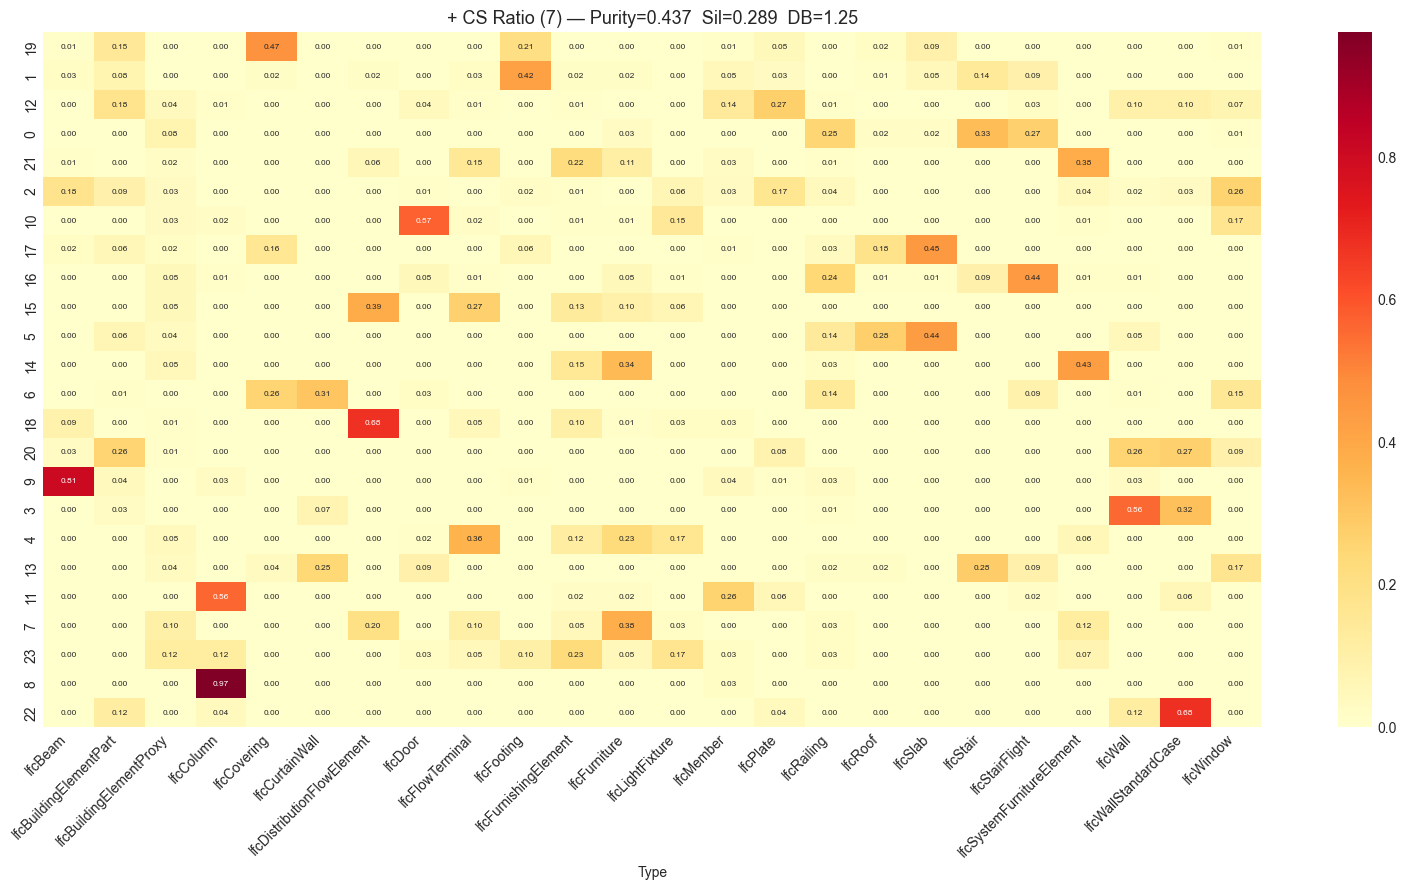

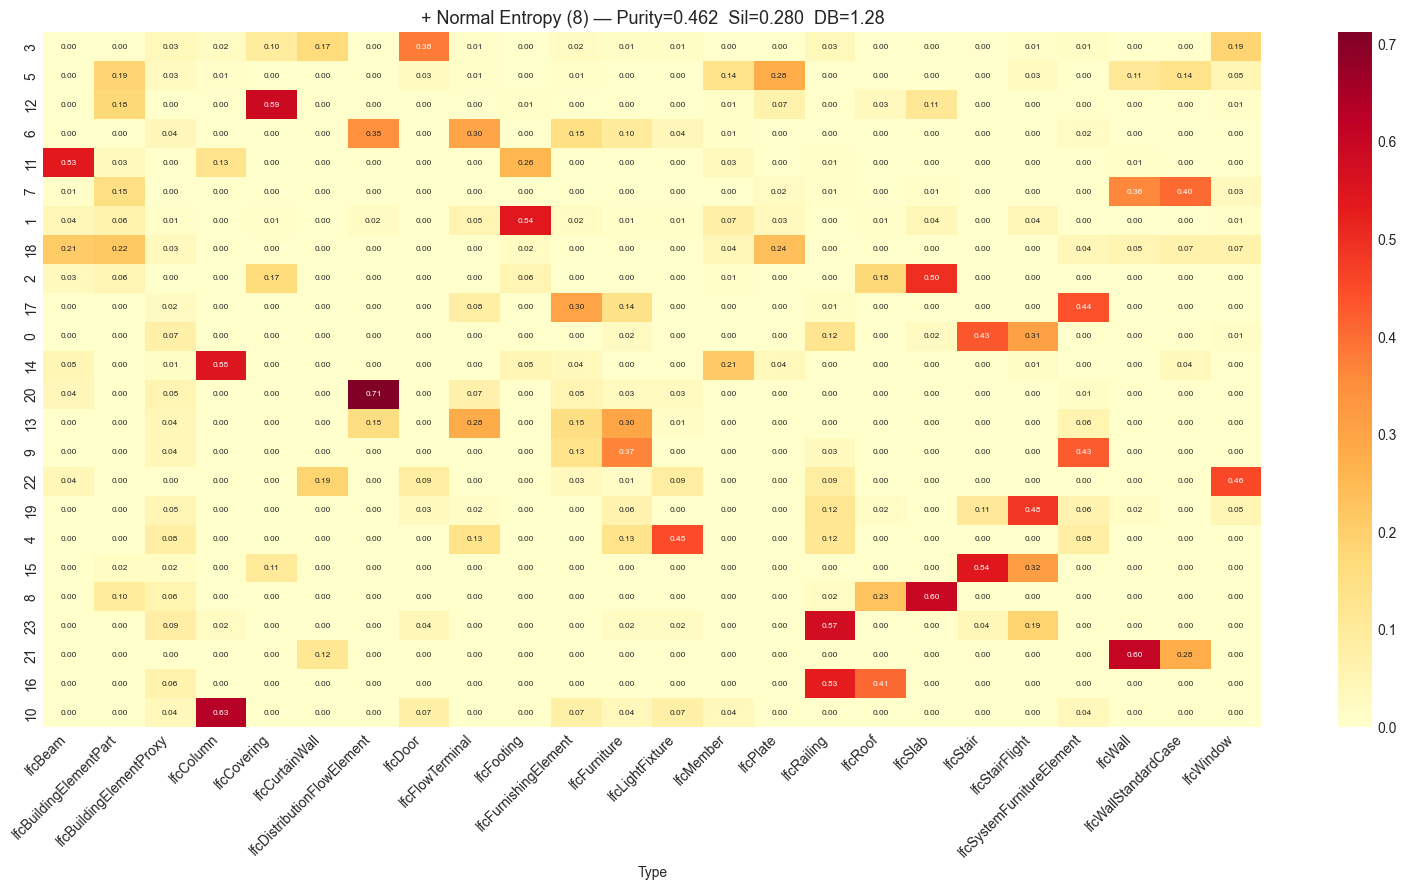

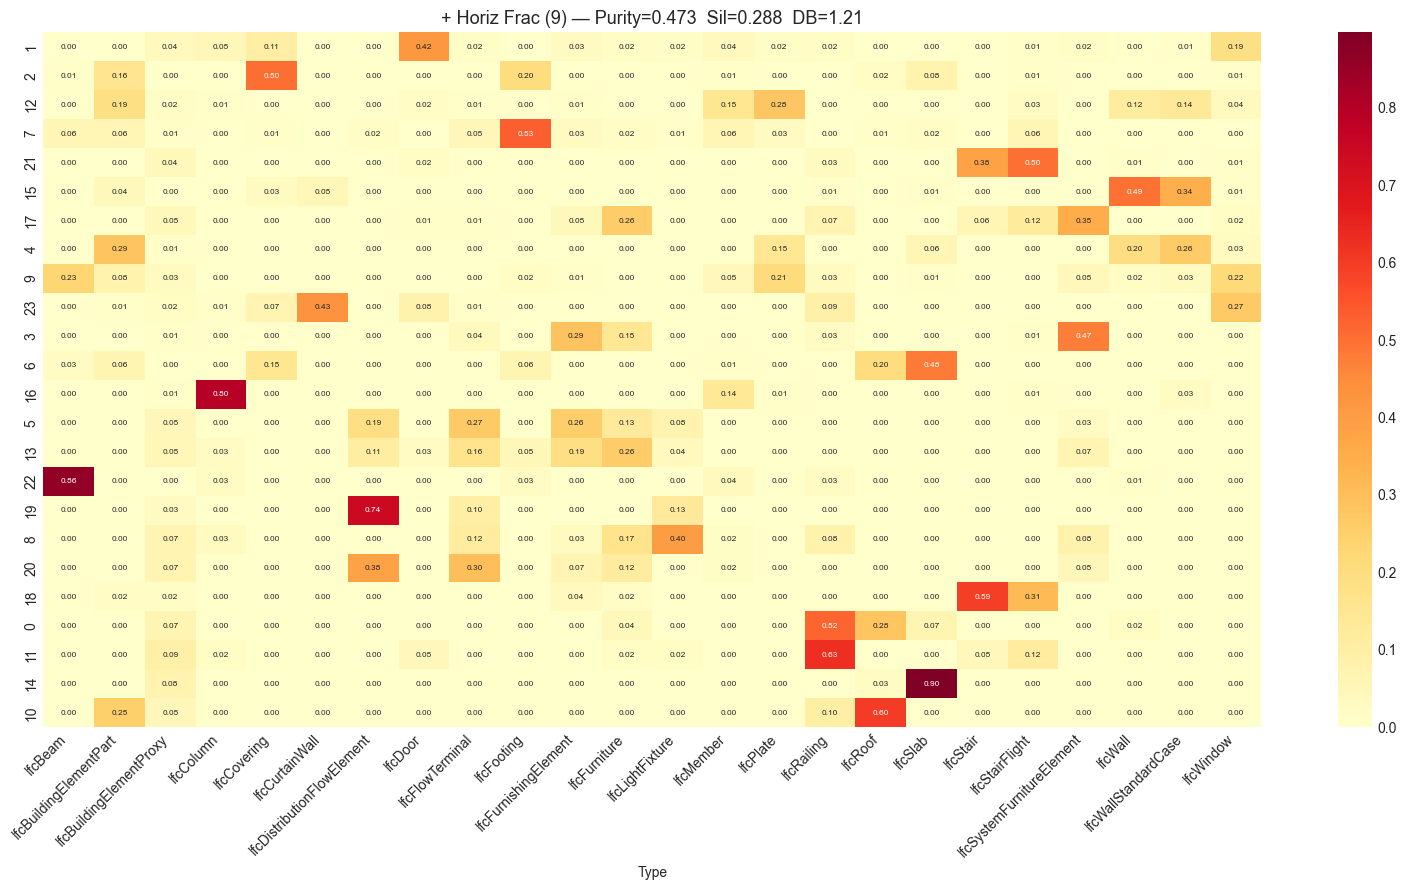

In [43]:
def title_metrics(X, lab, labels):
    p = compute_purity(lab, labels)
    s = silhouette_score(X, lab)
    db = davies_bouldin_score(X, lab)
    return f'Purity={p:.3f}  Sil={s:.3f}  DB={db:.2f}'

for name in configs:
    X_sc = RobustScaler().fit_transform(configs[name])
    lab = MiniBatchKMeans(24, batch_size=1024, n_init='auto', random_state=42).fit_predict(X_sc)
    ct = pd.crosstab(pd.Series(lab, name='Cluster'),
                     pd.Series(ifc_types_feat, name='Type'), normalize='index')
    ct = ct.reindex(pd.Series(lab).value_counts().index)

    fig, ax = plt.subplots(figsize=(16, 9))
    sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, annot_kws={'size': 6})
    ax.set_title(f'{name} — {title_metrics(X_sc, lab, ifc_types_feat)}', fontsize=13)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

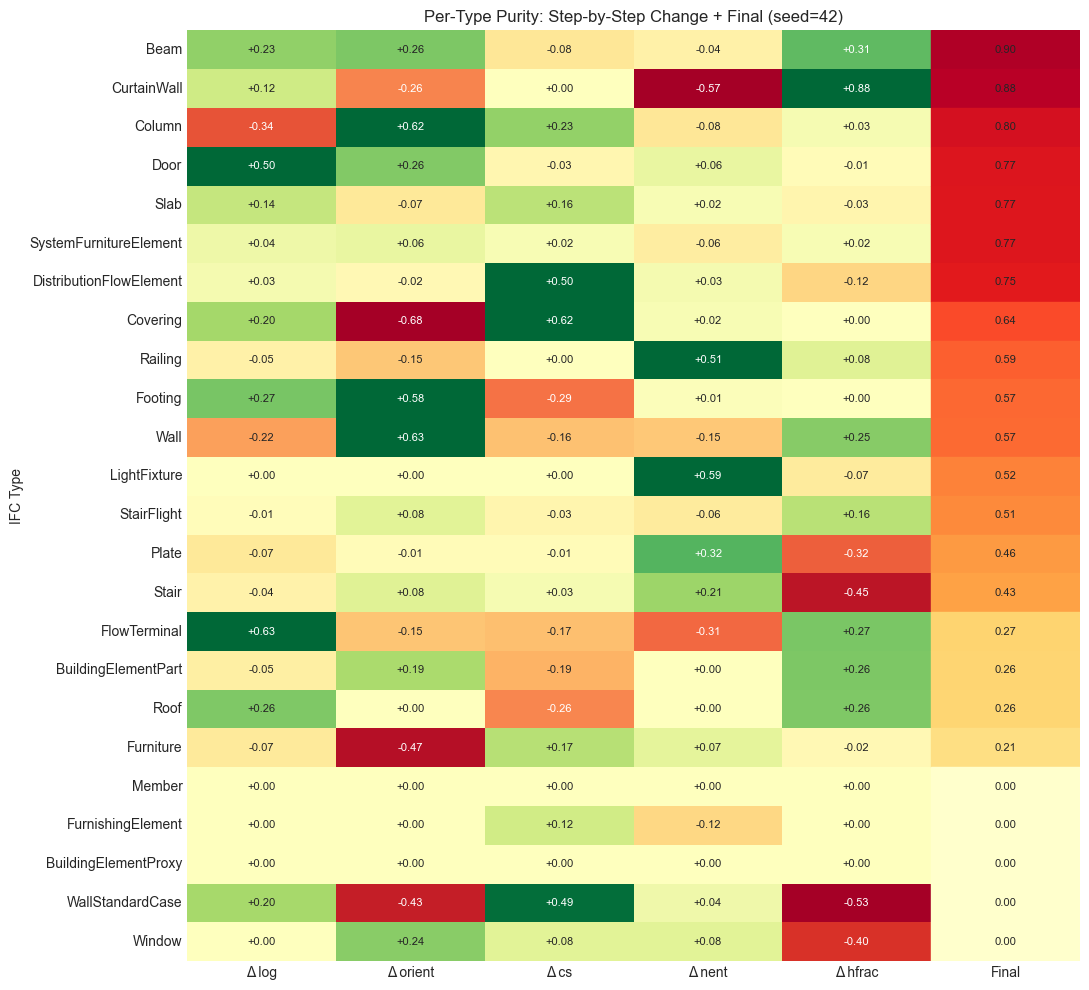

In [44]:
# Per-type purity progression
def per_type_purity(lab, true_labels):
    cluster_dominant = {}
    for c in np.unique(lab):
        mask = lab == c
        counts = pd.Series(true_labels[mask]).value_counts()
        cluster_dominant[c] = counts.index[0]
    type_purity = {}
    for t in np.unique(true_labels):
        t_mask = true_labels == t
        t_objects = t_mask.sum()
        correct = sum(1 for i in np.where(t_mask)[0] if cluster_dominant[lab[i]] == t)
        type_purity[t] = correct / t_objects
    return type_purity

config_names = list(configs.keys())
type_purities = {}
for name in config_names:
    X_sc = RobustScaler().fit_transform(configs[name])
    lab = MiniBatchKMeans(24, batch_size=1024, n_init='auto', random_state=42).fit_predict(X_sc)
    type_purities[name] = per_type_purity(lab, ifc_types_feat)

all_types = sorted(set(ifc_types_feat))
df_tp = pd.DataFrame({name: [type_purities[name].get(t, 0) for t in all_types]
                       for name in config_names}, index=all_types)
df_tp.index = df_tp.index.str.replace('Ifc', '')
df_tp = df_tp.sort_values(config_names[-1], ascending=False)

df_delta = pd.DataFrame(index=df_tp.index)
delta_names = ['Δ log', 'Δ orient', 'Δ cs', 'Δ nent', 'Δ hfrac']
for i in range(1, len(config_names)):
    prev, curr = config_names[i-1], config_names[i]
    df_delta[delta_names[i-1]] = df_tp[curr] - df_tp[prev]

df_delta['Final'] = df_tp[config_names[-1]]
n_delta = len(delta_names)

fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(df_delta.iloc[:, :-1], annot=True, fmt='+.02f', cmap='RdYlGn', vmin=-0.5, vmax=0.5, 
            center=0, ax=ax, cbar=False, annot_kws={'size': 8})
for i, idx in enumerate(df_delta.index):
    val = df_delta.loc[idx, 'Final']
    color = plt.cm.YlOrRd(val)
    ax.add_patch(plt.Rectangle((n_delta, i), 1, 1, fill=True, color=color))
    ax.text(n_delta + 0.5, i + 0.5, f'{val:.2f}', ha='center', va='center', fontsize=8)
ax.set_xlim(0, n_delta + 1)
ax.set_xticks([i + 0.5 for i in range(n_delta + 1)])
ax.set_xticklabels(delta_names + ['Final'])
ax.set_title('Per-Type Purity: Step-by-Step Change + Final (seed=42)', fontsize=12)
ax.set_xlabel(''); ax.set_ylabel('IFC Type')
plt.tight_layout(); plt.show()

---
## 5. Type Merging

Some IFC types are subtypes of one another in the IFC schema and geometrically indistinguishable:
- **Wall**: IfcWall + IfcWallStandardCase (IFC4 deprecated WallStandardCase)
- **Furniture**: IfcFurniture + IfcFurnishingElement + IfcSystemFurnitureElement (all furnishing subtypes)
- **MEP**: IfcDistributionFlowElement + IfcFlowTerminal (MEP distribution subtypes)
- **Stair**: IfcStair + IfcStairFlight (stair container vs individual flight — geometrically identical meshes)

24 → 19 types.

24 types -> 19 types

Config                    Types        Purity    Silhouette        DB (↓)        CH (↑)
---------------------------------------------------------------------------------------
Baseline (4, log)            24 0.330±0.009 0.321±0.008 0.996±0.024 1109±27
Baseline (4, log)            19 0.438±0.011 0.321±0.008 0.996±0.024 1109±27
+ Horiz Frac (9)             24 0.470±0.016 0.277±0.012 1.242±0.024 384±7
+ Horiz Frac (9)             19 0.592±0.020 0.277±0.012 1.242±0.024 384±7


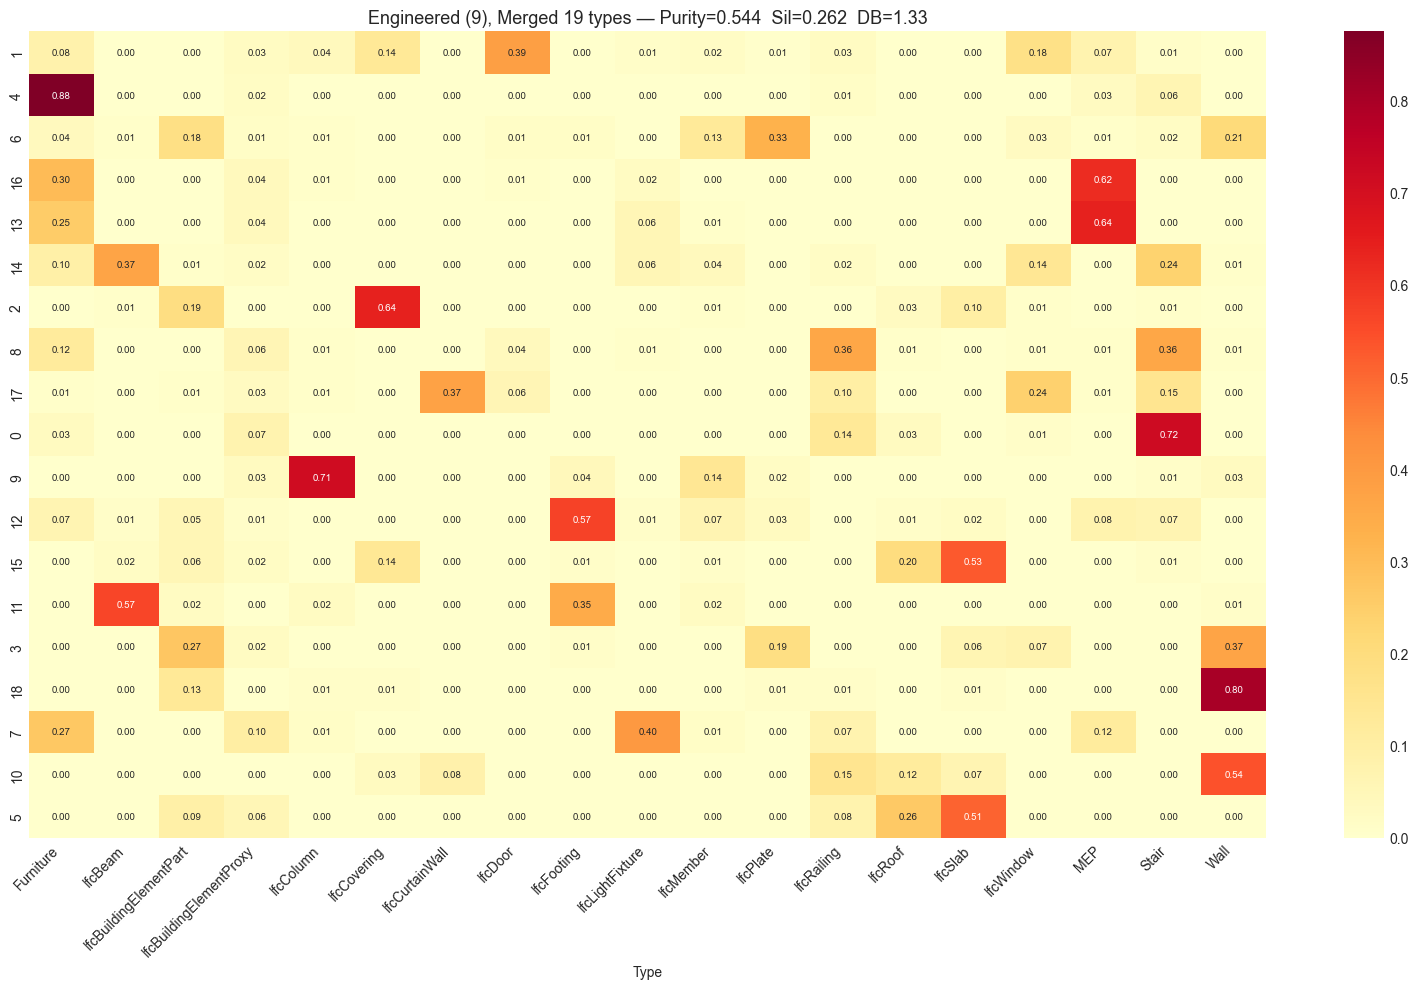

In [47]:
TYPE_MAP = {
    'IfcWall': 'Wall', 'IfcWallStandardCase': 'Wall',
    'IfcFurniture': 'Furniture', 'IfcFurnishingElement': 'Furniture',
    'IfcSystemFurnitureElement': 'Furniture',
    'IfcDistributionFlowElement': 'MEP', 'IfcFlowTerminal': 'MEP',
    'IfcStair': 'Stair', 'IfcStairFlight': 'Stair',
}
ifc_merged = np.array([TYPE_MAP.get(t, t) for t in ifc_types_feat])

print(f'{len(set(ifc_types_feat))} types -> {len(set(ifc_merged))} types\n')

header = f'{"Config":<25} {"Types":>5} {"Purity":>13} {"Silhouette":>13} {"DB (↓)":>13} {"CH (↑)":>13}'
print(header)
print('-' * len(header))
for name in ['Baseline (4, log)', '+ Horiz Frac (9)']:
    X = configs[name]
    r24 = eval_k24(X, ifc_types_feat)
    r19 = eval_k24(X, ifc_merged)
    for n_types, r in [(24, r24), (19, r19)]:
        print(f'{name:<25} {n_types:>5} {r["purity"][0]:.3f}±{r["purity"][1]:.3f}'
              f' {r["silhouette"][0]:.3f}±{r["silhouette"][1]:.3f}'
              f' {r["davies_bouldin"][0]:.3f}±{r["davies_bouldin"][1]:.3f}'
              f' {r["calinski_harabasz"][0]:.0f}±{r["calinski_harabasz"][1]:.0f}')

X_final_sc = RobustScaler().fit_transform(configs['+ Horiz Frac (9)'])
lab = MiniBatchKMeans(19, batch_size=1024, n_init='auto', random_state=42).fit_predict(X_final_sc)
ct = pd.crosstab(pd.Series(lab, name='Cluster'),
                 pd.Series(ifc_merged, name='Type'), normalize='index')
ct = ct.reindex(pd.Series(lab).value_counts().index)

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, annot_kws={'size': 7})
ax.set_title(f'Engineered (9), Merged 19 types — {title_metrics(X_final_sc, lab, ifc_merged)}', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

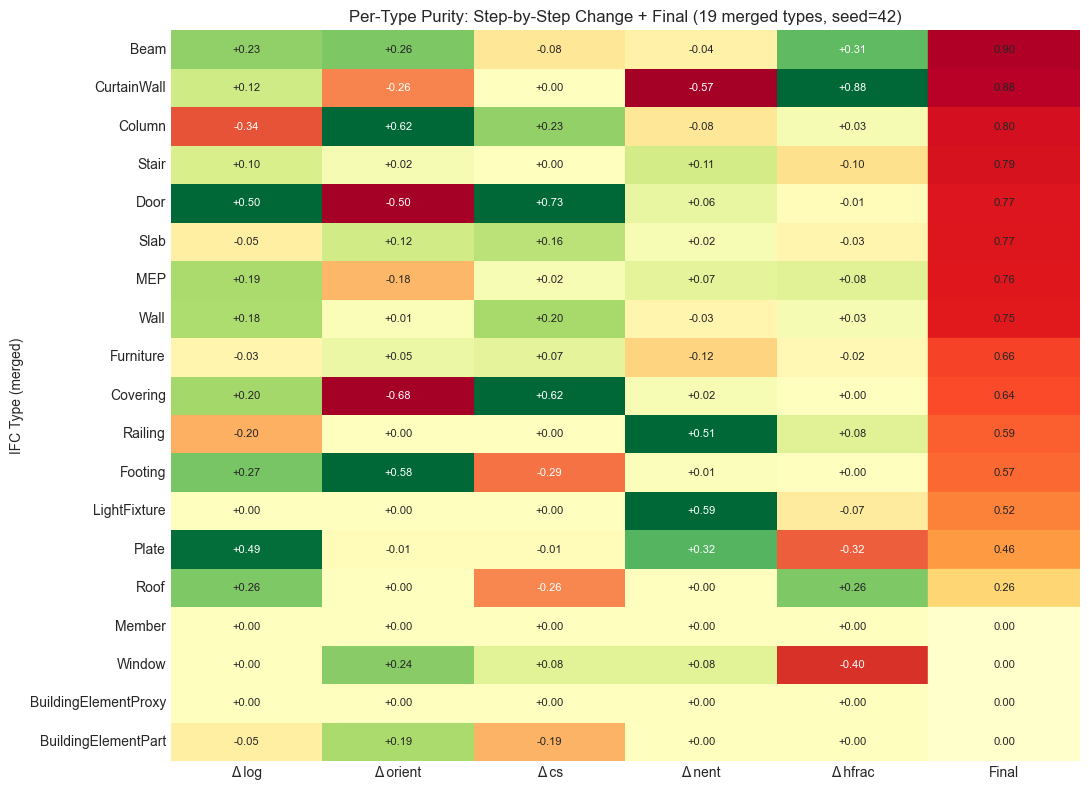

In [48]:
# Per-type purity deltas with merged types
type_purities_merged = {}
for name in config_names:
    X_sc = RobustScaler().fit_transform(configs[name])
    lab = MiniBatchKMeans(24, batch_size=1024, n_init='auto', random_state=42).fit_predict(X_sc)
    type_purities_merged[name] = per_type_purity(lab, ifc_merged)

all_merged = sorted(set(ifc_merged))
df_tp_merged = pd.DataFrame({name: [type_purities_merged[name].get(t, 0) for t in all_merged]
                              for name in config_names}, index=all_merged)
df_tp_merged.index = df_tp_merged.index.str.replace('Ifc', '')
df_tp_merged = df_tp_merged.sort_values(config_names[-1], ascending=False)

df_delta_merged = pd.DataFrame(index=df_tp_merged.index)
delta_names = ['Δ log', 'Δ orient', 'Δ cs', 'Δ nent', 'Δ hfrac']
for i in range(1, len(config_names)):
    prev, curr = config_names[i-1], config_names[i]
    df_delta_merged[delta_names[i-1]] = df_tp_merged[curr] - df_tp_merged[prev]

df_delta_merged['Final'] = df_tp_merged[config_names[-1]]
n_delta = len(delta_names)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(df_delta_merged.iloc[:, :-1], annot=True, fmt='+.02f', cmap='RdYlGn', vmin=-0.5, vmax=0.5, 
            center=0, ax=ax, cbar=False, annot_kws={'size': 8})
for i, idx in enumerate(df_delta_merged.index):
    val = df_delta_merged.loc[idx, 'Final']
    color = plt.cm.YlOrRd(val)
    ax.add_patch(plt.Rectangle((n_delta, i), 1, 1, fill=True, color=color))
    ax.text(n_delta + 0.5, i + 0.5, f'{val:.2f}', ha='center', va='center', fontsize=8)
ax.set_xlim(0, n_delta + 1)
ax.set_xticks([i + 0.5 for i in range(n_delta + 1)])
ax.set_xticklabels(delta_names + ['Final'])
ax.set_title('Per-Type Purity: Step-by-Step Change + Final (19 merged types, seed=42)', fontsize=12)
ax.set_xlabel(''); ax.set_ylabel('IFC Type (merged)')
plt.tight_layout(); plt.show()

---
## Summary

| Feature | Source | Measures | Distinguishes |
|---|---|---|---|
| Length (log) | OBB | Object scale | Global size grouping |
| CrossSectionArea (log) | OBB | Cross-section size | Thin vs thick objects |
| Volume (log) | OBB | Overall size | Small vs large objects |
| NumVertices (log) | Mesh | Mesh complexity | Simple vs detailed geometry |
| pc1_z | PCA on vertices | Longest axis vs vertical | Column vs Beam |
| pc3_z | PCA on vertices | Thinnest axis vs vertical | Wall vs Slab |
| CS aspect ratio | PCA eigenvalues | Cross-section shape | Column (square) vs Plate (thin) |
| Normal entropy | Face normals | Surface complexity | Slab (flat, ~0) vs Railing (complex, ~1) |
| Horiz surface frac | Face normals + areas | Directional surface composition | Slab (~1.0) vs Wall (~0.0) vs Roof (moderate) |